In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, constants
import matplotlib.animation as animation
from PIL import Image

## Esercizio 1: Filtro Passa Basso

Il circuito in figura è un **Filtro Passa Basso**, ovvero un circuito il cui comportamento è quello di "filtrare" i segnali ad alta frequenza. Infatti considerato che $z_C = \frac{1}{wc} \; \text{,} \; z_R = R $ sono le impedenze rispettivamente di CAPACITORE e RESISTENZA:
- ad **alte frequenze** $z_C \rightarrow 0$ quindi tutto il segnale in ingresso si ritrova all'uscita della resistenza;
- a **basse frequenze** $z_C \rightarrow \infty$ quindi tutto il segnale in ingresso si ritrova all'uscita della capacità;

Di seguito è mostrato lo schema del circuto e un diagramma tipico di un filtro passa basso del Guadagno $A$ in funzione della frequenza $ \omega$.

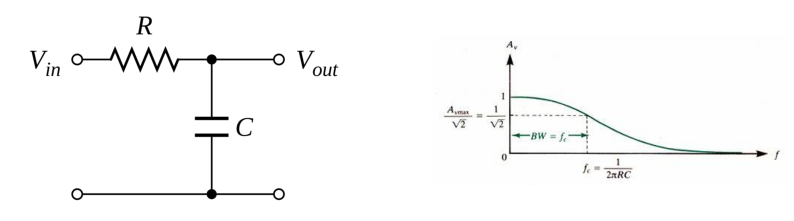

In [2]:
%matplotlib inline
fig, ax=plt.subplots(1,2, figsize=(10,7))
ax[0].imshow(np.asarray(Image.open('/home/nicola_polito/MCF/E8/Pbf.png')))
ax[1].imshow(np.asarray(Image.open('/home/nicola_polito/MCF/E8/grafico_pb.png')))
for ax in fig.get_axes():
    ax.axis('off')
plt.show()

Indicando con $I$ la corrente che attraversa la resistenza $R$  e il condensatore $C$ e con $Q$ la carica elettrica:
$$ V_{in} - V_{out} = I*R \quad \text{,} \quad C V_{out}=Q \quad \text{,} \quad \frac{dQ}{dt}=I $$

da cui possiamo ricavare, supponendo $R$ e $C$ costanti:
$$ C \frac{dV_{out}}{dt}= \frac{dQ}{dt} = I $$

inoltre,
$$ I = \frac{V_{in} - V_{out}}{R} $$

Segue l'equazione differenziale:
$$ \frac{dV_{out}}{dt} = \frac{1}{RC} (V_{in} - V_{out}) $$

Una sua soluzione descrive l'andamento della corrente in uscita dal circuito nel tempo.

**Richieste**: 
- Risolvere l'equazione differenziale per $V_{out}$ data la tensione al generatore $V_{in}$
- Definire $V_{in}$ per il tempo $t \in [0-10]$ in modo alternato nel seguente modo:

    - $V_{in}(t) = +1 \; \text{ se [t] è pari} \; \text{,} \; -1 \; \text{ se [t] è dispari}$

- Produrre il grafico di $V_{in}$ e $V_{out}$ nel tempo per diversi valori del rapporto $R/C$:

    - $ RC = 1 \quad \text{,} \quad RC = 0.5 \quad \text{,} \quad RC = 0.1 \;$
    con la condizione iniziale $V_{out}(0)=0$.
    
- Salvare i risultati $(t, V_{in}(t), V_{out}(t))$ per i tre valori di $RC$ in uno stesso file *.csv* .
- Ripetere l'analisi con un potenziale in ingresso $V_{in}$ diverso.

In [3]:
#casi1:  R fisso, aumento C --> A1, B1, C1
#casi2:  C fisso, aumento R --> A2, B2, C2

R = 100e3  # 100 KOhm
C2 = 10e-6 # 10 muF
C1 = 5e-6  # 5 muF
C =  1e-6  # 0.1 muF
R1 = 500e3 # 500 kOhm
R2 = 1e6   # 1MOhm

# Casi A: 0.1, casi B: 0.5, casi C: 1.0
lR=np.array([R, R1, R2], dtype=float)
lC=np.array([C, C1, C2], dtype=float)

#creo un dizionario con i casi
key=np.array(['A1', 'B1', 'C1', 'A2', 'B2','C2'], dtype=str)
melds=np.array([[R,C], [R,C1], [R,C2], [R,C], [R1,C], [R2,C]])
for i in melds:
    print(i[0]*i[1])

print()

casi={}
for i,j in zip(key,melds):
    casi[i]=j

#stampo valori dizionario
for e,f in zip(casi.keys(), casi.values()):
    print('CASO {:s} : R ={:10.1f} , C = {:3.7f}'.format(e, f[0], f[1]))

0.09999999999999999
0.5
1.0
0.09999999999999999
0.5
1.0

CASO A1 : R =  100000.0 , C = 0.0000010
CASO B1 : R =  100000.0 , C = 0.0000050
CASO C1 : R =  100000.0 , C = 0.0000100
CASO A2 : R =  100000.0 , C = 0.0000010
CASO B2 : R =  500000.0 , C = 0.0000010
CASO C2 : R = 1000000.0 , C = 0.0000010


In [4]:
# Potenziale in ingresso

# array tempi 
time1 = np.linspace(0, 20, 200)
#print('time:', time1, '\n')

# array V = 1
vin = np.ones(len(time1)) 
#maschera per selezionare valori interi dispari (non divisibili per 2) 
odd_mask = time1.astype(int) %2 != 0
#print(odd_mask)

# assegno valori per interi dispari
vin[odd_mask] = -1

#print('vin:', vin)

# condizione iniziale V_out(0)=0
v0=0

def dt(t_ax):
    t=0
    delta=np.empty(0)
    for k in t_ax:
        if(k != 0):
            d=k-t
            delta=np.append(delta,d)
            t=k
    #print(delta)
    h= np.mean(delta)
    return h

dt_time1 =  dt(time1)

In [5]:
#equazione differenziale per V_out
def dvout(vv, tt, v0, pstart ):
    c1=1/pstart[0]*pstart[1]
    c2=vv-v0
    return c1*c2

In [6]:
#Risoluzione Equazioni potenziale vin

def eq_dvout(deltat, pstart, inputs, ticket):
    sol=np.empty(0)
    time_arr= np.empty(0)
    t_sx=0
    t_dx=deltat
    for k in inputs:
        time_arr=np.array([t_sx, t_dx])
        #print(time_arr)
        s=integrate.odeint(dvout, pstart, time_arr, args=(k, casi[ticket]))
        sol=np.append(sol, s[1])
        t_sx=t_dx
        t_dx=t_sx+deltat
    return sol

# CASO A1
vout_s1=eq_dvout(dt_time1,v0,vin,key[0])
#CASO B1
vout_s2=eq_dvout(dt_time1,v0,vin,key[1])
#CASO C1
vout_s3=eq_dvout(dt_time1,v0,vin,key[2])
#CASO A2
vout_s4=eq_dvout(dt_time1,v0,vin,key[3])
#CASO B2
vout_s5=eq_dvout(dt_time1,v0,vin,key[4])
#CASO C2
vout_s6=eq_dvout(dt_time1,v0,vin,key[5])

vout_sr=np.array([vout_s1, vout_s2, vout_s3])
vout_sc=np.array([vout_s4, vout_s5, vout_s6])

In [7]:
#Creazione data file --> un unico file deve contenere i dati per tutte le configurazioni di RC
pb_data=open('/home/nicola_polito/MCF/E8/data_pb.txt', 'wt')
pb_data.write('RC , time (s) , Vin (V) , Vout (V) \n')
r=12
for e,l in zip(casi.values(), range(3)):
    pb_data.write('{:s}{:5s}{:}'.format('',str(round(e[0]*e[1], 2)), '\n'))

    for i,j,k in zip(time1 , vin, vout_sr[l]):
        pb_data.write('{:6s}{:>6s},{:>8s},{:>10s}{:}'.format('',str(round(i,3)),str(j),str(round(k,r)),'\n'))
pb_data.close()

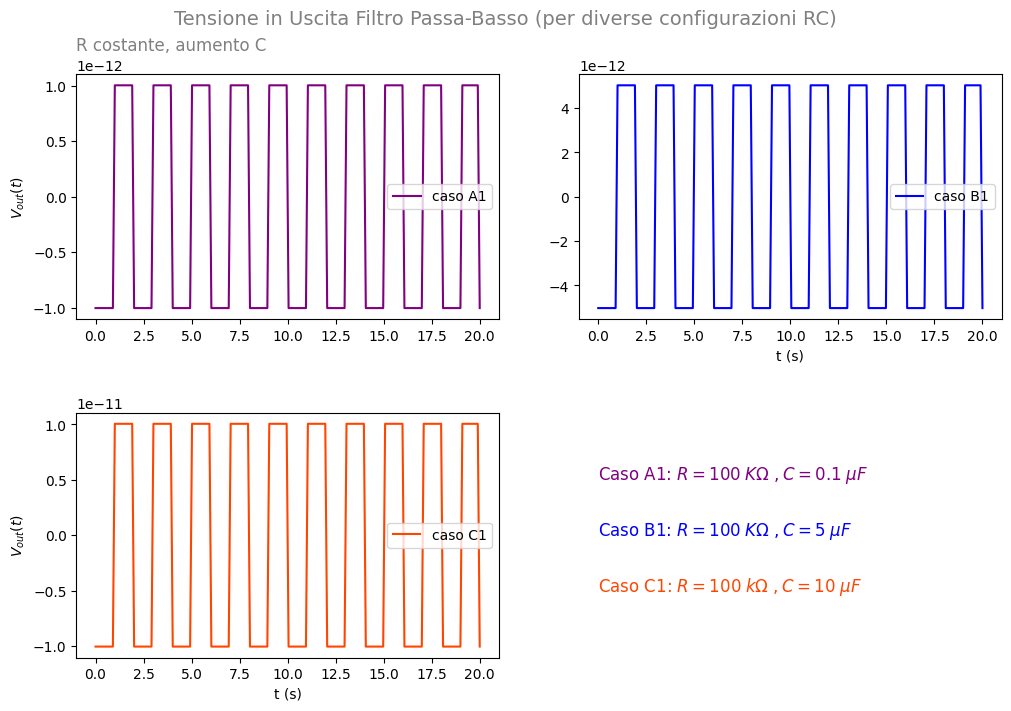

In [8]:
# Grafici soluzioni nei tre casi (nel tempo)
fig = plt.figure(figsize=(10,7), layout='constrained')
gs = fig.add_gridspec(2,2, hspace=0.1, wspace=0.1)
(ax1, ax2), (ax3, ax4)= gs.subplots()
fig.suptitle('Tensione in Uscita Filtro Passa-Basso (per diverse configurazioni RC)', fontsize=14, color='grey')

ax1.set_title('R costante, aumento C', color='grey', loc='left')
ax1.plot(time1, vout_sr[0], color='purple', label='caso A1')
#ax1.set_xlabel('t (s)', fontsize=10)
ax1.set_ylabel(r'$ V_{out}(t)$')
ax1.legend(fontsize=10)

ax2.plot(time1, vout_sr[1], color='blue', label='caso B1')
ax2.set_xlabel('t (s)', fontsize=10)
#ax2.set_ylabel(r'$\theta(t)$')
ax2.legend(fontsize=10)

ax3.plot(time1, vout_sr[2], color='orangered', label='caso C1')
ax3.set_xlabel('t (s)', fontsize=10)
ax3.set_ylabel(r'$ V_{out}(t)$')
ax3.legend(fontsize=10)

ax4.plot(time1,time1, alpha=0)
ax4.axis('off')
ax4.text(0,15, r'Caso A1: $R=100 \; K \Omega \; \text{,} \; C=0.1 \; \mu F$', fontsize=12, color ='purple')
ax4.text(0,10, r'Caso B1: $R=100  \; K \Omega \; \text{,} \; C=5 \;   \mu F$', fontsize=12, color ='blue')
ax4.text(0,5,  r'Caso C1: $R=100   \; k \Omega \; \text{,} \; C=10 \;  \mu F $', fontsize=12, color ='orangered')

plt.show()

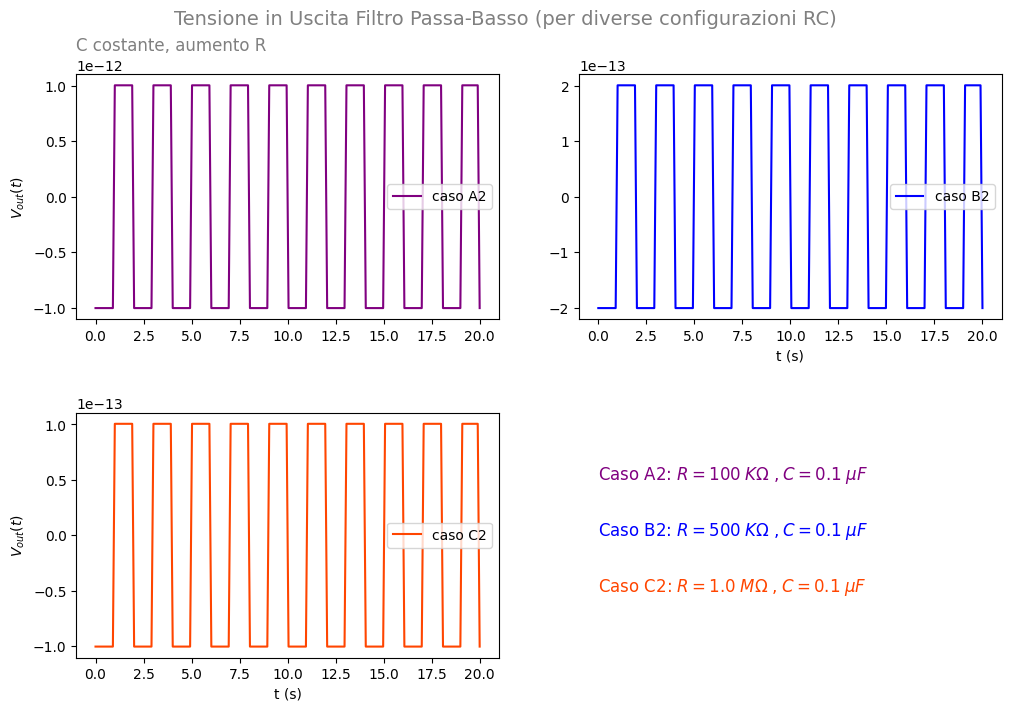

In [9]:
# Grafici soluzioni nei tre casi (nel tempo)
fig = plt.figure(figsize=(10,7), layout='constrained')
gs = fig.add_gridspec(2,2, hspace=0.1, wspace=0.1)
(ax1, ax2), (ax3, ax4)= gs.subplots()
fig.suptitle('Tensione in Uscita Filtro Passa-Basso (per diverse configurazioni RC)', fontsize=14, color='grey')

ax1.set_title('C costante, aumento R', color='grey', loc='left')
ax1.plot(time1, vout_sc[0], color='purple', label='caso A2')
#ax1.set_xlabel('t (s)', fontsize=10)
ax1.set_ylabel(r'$ V_{out}(t)$')
ax1.legend(fontsize=10)

ax2.plot(time1, vout_sc[1], color='blue', label='caso B2')
ax2.set_xlabel('t (s)', fontsize=10)
#ax2.set_ylabel(r'$\theta(t)$')
ax2.legend(fontsize=10)

ax3.plot(time1, vout_sc[2], color='orangered', label='caso C2')
ax3.set_xlabel('t (s)', fontsize=10)
ax3.set_ylabel(r'$ V_{out}(t)$')
ax3.legend(fontsize=10)

ax4.plot(time1,time1, alpha=0)
ax4.axis('off')
ax4.text(0,15, r'Caso A2: $R=100 \; K \Omega \; \text{,} \; C=0.1 \; \mu F$', fontsize=12, color ='purple')
ax4.text(0,10, r'Caso B2: $R=500  \; K \Omega \; \text{,} \; C=0.1 \; \mu F$', fontsize=12, color ='blue')
ax4.text(0,5,  r'Caso C2: $R=1.0   \; M \Omega \; \text{,} \; C=0.1 \; \mu F $', fontsize=12, color ='orangered')

plt.show()

Si evidenzia che, per uno stesso potenziale in ingresso, diminuendo il prodotto $RC$, diminuisce la tensione all'uscita della resistenza.
In particolare:
- se aumento R per un certo valore di C, la tensione all'uscita di R diminuisce;
- se aumento C per un certo valore di R, la tensione all'uscita di R aumenta.

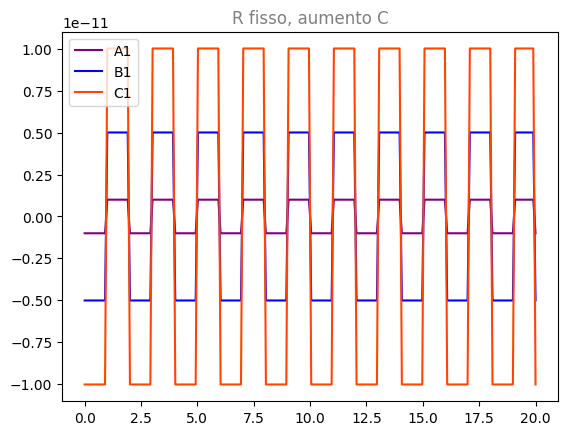

In [10]:
#R fisso, aumento C --> la tensione in uscita aumenta
plt.title('R fisso, aumento C', color = 'grey')
plt.plot(time1, vout_sr[0], label='A1', color='purple')
plt.plot(time1, vout_sr[1], label='B1', color='blue')
plt.plot(time1, vout_sr[2], label='C1', color='orangered')
plt.legend()

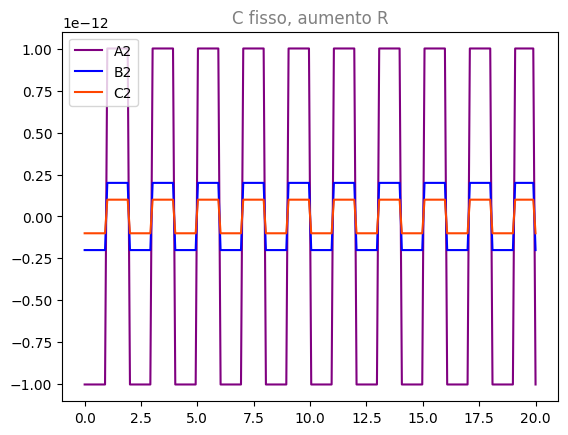

In [11]:
#C fisso, aumento R --> la tensione in uscita diminuisce
plt.title('C fisso, aumento R', color = 'grey')
plt.plot(time1, vout_sc[0], color='purple', label='A2')
plt.plot(time1, vout_sc[1], color='blue',label='B2')
plt.plot(time1, vout_sc[2], color='orangered',label='C2')
plt.legend()

Adopero segnali in ingresso sinusoidali di uguale ampiezza ma diversa frequenza.

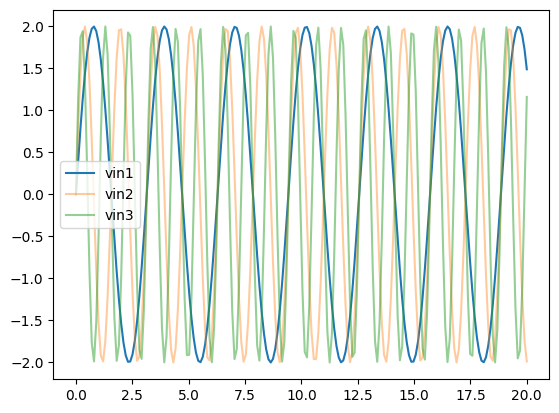

In [12]:
#potenziale in ingresso sinusoidale
vin1=2*np.sin(2*time1)
vin2=2*np.sin(4*time1)
vin3=2*np.sin(6*time1)

plt.plot(time1, vin1, label='vin1')
plt.plot(time1, vin2, label='vin2', alpha=0.4)
plt.plot(time1,vin3,label='vin3', alpha=0.5)
plt.legend()

In [13]:
#Risoluzione Equazioni potenziale sinusoidali
# CASO A1
vout_s11=eq_dvout(dt_time1,v0,vin1,key[0])
vout_s12=eq_dvout(dt_time1,v0,vin1,key[1])
vout_s13=eq_dvout(dt_time1,v0,vin1,key[2])
#CASO B1
vout_s21=eq_dvout(dt_time1,v0,vin2,key[0])
vout_s22=eq_dvout(dt_time1,v0,vin2,key[1])
vout_s23=eq_dvout(dt_time1,v0,vin2,key[2])
#CASO C1
vout_s31=eq_dvout(dt_time1,v0,vin3,key[0])
vout_s32=eq_dvout(dt_time1,v0,vin3,key[1])
vout_s33=eq_dvout(dt_time1,v0,vin3,key[2])

#CASO A2
vout_s41=eq_dvout(dt_time1,v0,vin1,key[3])
vout_s42=eq_dvout(dt_time1,v0,vin1,key[4])
vout_s43=eq_dvout(dt_time1,v0,vin1,key[5])

#CASO B2
vout_s51=eq_dvout(dt_time1,v0,vin2,key[3])
vout_s52=eq_dvout(dt_time1,v0,vin2,key[4])
vout_s53=eq_dvout(dt_time1,v0,vin2,key[5])

#CASO C2
vout_s61=eq_dvout(dt_time1,v0,vin3,key[3])
vout_s62=eq_dvout(dt_time1,v0,vin3,key[4])
vout_s63=eq_dvout(dt_time1,v0,vin3,key[5])

#R fisso 
vout_s1r=np.array([vout_s11, vout_s12, vout_s13])
vout_s2r=np.array([vout_s21, vout_s22, vout_s23])
vout_s3r=np.array([vout_s31, vout_s32, vout_s33])
#C fisso
vout_s1c=np.array([vout_s41, vout_s42, vout_s43])
vout_s2c=np.array([vout_s51, vout_s52, vout_s53])
vout_s3c=np.array([vout_s61, vout_s62, vout_s63])

Text(0, 5, 'Caso C1: $R=100    \\; k \\Omega \\; \\text{,} \\; C=10    \\; \\mu F $')

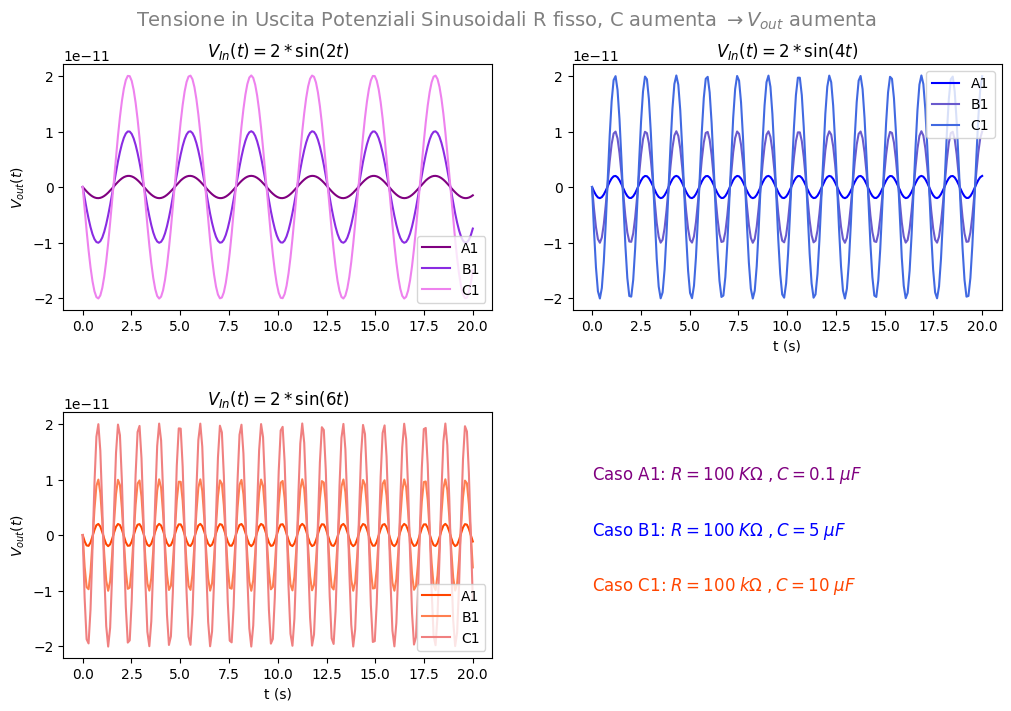

In [14]:
fig = plt.figure(figsize=(10,7), layout='constrained')
gs = fig.add_gridspec(2,2, hspace=0.1, wspace=0.1)
(ax1, ax2), (ax3, ax4)= gs.subplots()
fig.suptitle(r'Tensione in Uscita Potenziali Sinusoidali R fisso, C aumenta $\rightarrow V_{out}$ aumenta', fontsize=14, color='grey')

ax1.set_title(r'$V_{In}(t) = 2*\sin(2t)$')
ax1.plot(time1, vout_s1r[0], color='purple', label= 'A1')
ax1.plot(time1, vout_s1r[1], color='blueviolet', label='B1')
ax1.plot(time1, vout_s1r[2], color='violet', label='C1')
#ax1.set_xlabel('t (s)', fontsize=10)
ax1.set_ylabel(r'$ V_{out}(t)$')
ax1.legend(fontsize=10)

ax2.set_title(r'$V_{In}(t) = 2*\sin(4t)$')
ax2.plot(time1, vout_s2r[0], color='blue', label='A1')
ax2.plot(time1, vout_s2r[1], color='slateblue', label='B1')
ax2.plot(time1, vout_s2r[2], color='royalblue', label='C1')
ax2.set_xlabel('t (s)', fontsize=10)
#ax2.set_ylabel(r'$\theta(t)$')
ax2.legend(fontsize=10)

ax3.set_title(r'$V_{In}(t) = 2*\sin(6t)$')
ax3.plot(time1, vout_s3r[0], color='orangered', label='A1')
ax3.plot(time1, vout_s3r[1], color='coral', label='B1')
ax3.plot(time1, vout_s3r[2], color='lightcoral', label='C1')
ax3.set_xlabel('t (s)', fontsize=10)
ax3.set_ylabel(r'$ V_{out}(t)$')
ax3.legend(fontsize=10)

ax4.plot(time1,time1, alpha=0)
ax4.axis('off')
ax4.text(0,15,r'Caso A1: $R=100 \; K \Omega \; \text{,} \; C=0.1 \; \mu F$', fontsize=12, color ='purple')
ax4.text(0,10,r'Caso B1: $R=100  \; K \Omega \; \text{,} \; C=5    \; \mu F$', fontsize=12, color ='blue')
ax4.text(0,5, r'Caso C1: $R=100    \; k \Omega \; \text{,} \; C=10    \; \mu F $', fontsize=12, color ='orangered')

Text(0, 5, 'Caso C2: $R=1.0   \\; M \\Omega \\; \\text{,} \\; C=0.1 \\; \\mu F $')

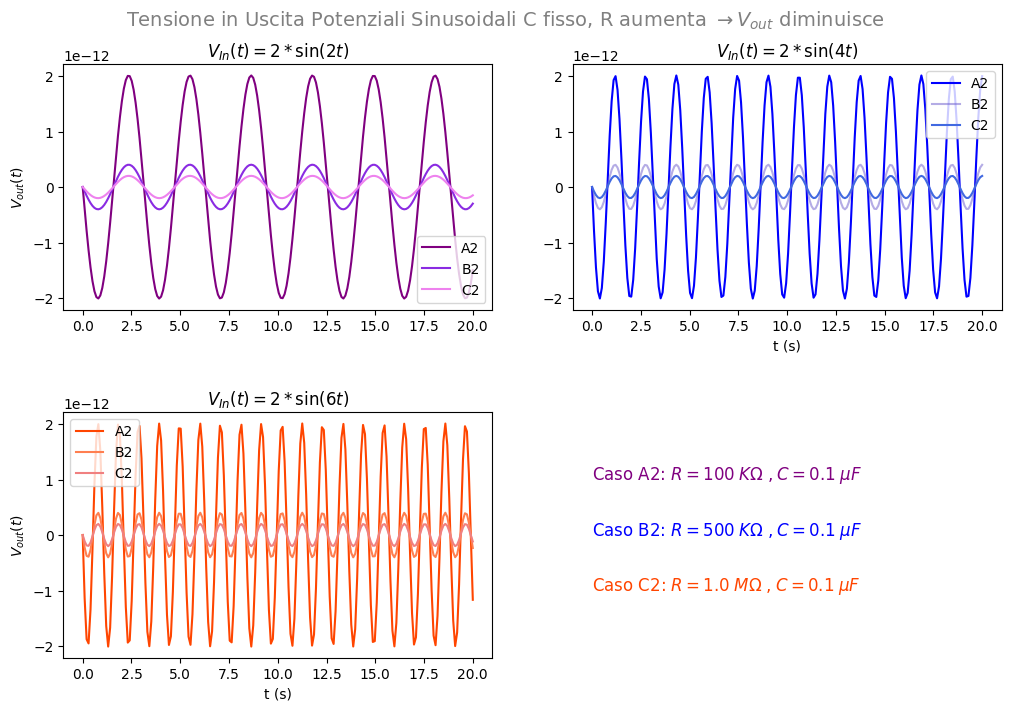

In [15]:
fig = plt.figure(figsize=(10,7), layout='constrained')
gs = fig.add_gridspec(2,2, hspace=0.1, wspace=0.1)
(ax1, ax2), (ax3, ax4)= gs.subplots()
fig.suptitle(r'Tensione in Uscita Potenziali Sinusoidali C fisso, R aumenta $\rightarrow V_{out}$ diminuisce', fontsize=14, color='grey')

ax1.set_title(r'$V_{In}(t) = 2*\sin(2t)$')
ax1.plot(time1, vout_s1c[0], color='purple', label='A2')
ax1.plot(time1, vout_s1c[1], color='blueviolet', label='B2')
ax1.plot(time1, vout_s1c[2], color='violet', label='C2')
#ax1.set_xlabel('t (s)', fontsize=10)
ax1.set_ylabel(r'$ V_{out}(t)$')
ax1.legend(fontsize=10)

ax2.set_title(r'$V_{In}(t) = 2*\sin(4t)$')
ax2.plot(time1, vout_s2c[0], color='blue', label='A2')
ax2.plot(time1, vout_s2c[1], color='slateblue', label='B2', alpha=0.5)
ax2.plot(time1, vout_s2c[2], color='royalblue', label='C2')
ax2.set_xlabel('t (s)', fontsize=10)
#ax2.set_ylabel(r'$\theta(t)$')
ax2.legend(fontsize=10)

ax3.set_title(r'$V_{In}(t) = 2*\sin(6t)$')
ax3.plot(time1, vout_s3c[0], color='orangered', label='A2')
ax3.plot(time1, vout_s3c[1], color='coral', label='B2')
ax3.plot(time1, vout_s3c[2], color='lightcoral', label='C2')
ax3.set_xlabel('t (s)', fontsize=10)
ax3.set_ylabel(r'$ V_{out}(t)$')
ax3.legend(fontsize=10)

ax4.plot(time1,time1, alpha=0)
ax4.axis('off')
ax4.text(0,15,r'Caso A2: $R=100 \; K \Omega \; \text{,} \; C=0.1 \; \mu F$', fontsize=12, color ='purple')
ax4.text(0,10,r'Caso B2: $R=500  \; K \Omega \; \text{,} \; C=0.1 \; \mu F$', fontsize=12, color ='blue')
ax4.text(0,5, r'Caso C2: $R=1.0   \; M \Omega \; \text{,} \; C=0.1 \; \mu F $', fontsize=12, color ='orangered')

## Esercizio 2 : Pendolo

 Il moto di una massa $m$ in un pendolo semplice può essere descritto dalle oscillazioni che la massa compie attorno all'asse del pendolo, individuato dalla normale rispetto al centro di gravità.

Si riduce cioè ad un moto unidimensionale che è possibile descrivere attraverso la variazione della variabile $\theta$ che è l'angolo che la massa forma rispetto all'asse del pendolo ed è dunque della forma $\theta (t) $.

L'equazione del moto è la seguente:
$$ m l \frac{ d^2 \theta}{dt^2} = -m g \sin( \theta) \quad \Rightarrow \quad \frac{d^2 \theta}{dt^2} = - \frac{g}{l} \sin( \theta) $$

dove $m$ è la massa e $l$ la lunghezza del filo.

Si tratta di una equazione differenziale al secondo ordine in una variabile, che può essere risolta come un sistema di due equazioni scalari al primo ordine definendo $ \frac{ d \theta}{dt} \stackrel{.}{=} \omega$:
$$ \left ( \frac{d \theta}{dt}= \omega \quad \text{,} \quad \frac{d \omega}{dt} = -\frac{g}{l} \sin ( \theta) \right) $$

Il risultato dell'equazione al secondo ordine è raccolta dal vettore $\mathbf{r}( \theta, \omega) \;$.

**Richieste**: 
- Risolvere le equazioni differenziali che descrivono il moto del pendolo semplice per diverse condizioni iniziali:
    - A) $l=0.5$ m , $\theta_0 = 45°$ , $ \omega_0 = 0 \;$;
    - B) $l=1$ m , $\theta_0 = 45°$ , $ \omega_0 = 0 \;$;
    - C) $l=0.5$ m , $\theta_0 = 30°$ , $ \omega_0 = 0 \;$;

- Trovare la legge oraria $\theta(t)$ e produrre un grafico di $ \theta$ in funzione del tempo per le diverse condizioni iniziali;

- Confrontare i grafici di $ \theta$ vs $t$ per le diverse condizioni iniziali e fare le dovute considerazioni teoriche.

In [16]:
def eq_pendolo(pstart, tt, l):
    """eq_pendolo(pstart, tt, l) funzione per soluzione equazione differenziale del moto di un pendolo semplice

    Parametri
    ---------
    pstart= [ theta0, w0]: posizione iniziale e velocità angolare iniziale
    tt                   : asse dei tempi
    g                    : accelerazione gravitazionale
    l                    : lunghezza fune pendolo 

    Restituisce:
    ------------
    [dodt, dwdt] soluzione dell'equazione differenziale al secondo ordine per velocità ed accelerazione angolari
    """

    g=constants.g
    dodt=pstart[1]
    theta=pstart[0]*np.pi/180 #conversione in radianti
    dwdt=- g/l * np.sin(theta)
    return np.array([dodt, dwdt])

#condizioni iniziali
l_val=np.array([0.5, 1.0]) #m
cauchy_a=np.array([30, 0]) 
cauchy_b=np.array([45, 0])

#asse dei tempi
dt=0.05 #s
time2=np.arange(0, 40, dt)

In [17]:
pa_solved=integrate.odeint(eq_pendolo, cauchy_b, time2, args=(l_val[0],)) #caso A
pb_solved=integrate.odeint(eq_pendolo, cauchy_b, time2, args=(l_val[1],)) #caso B
pc_solved=integrate.odeint(eq_pendolo, cauchy_a, time2, args=(l_val[0],)) #caso C
p_solutions=np.array([pa_solved, pb_solved, pc_solved])

#print(pa_solved)
#print(pa_solved[:,0])

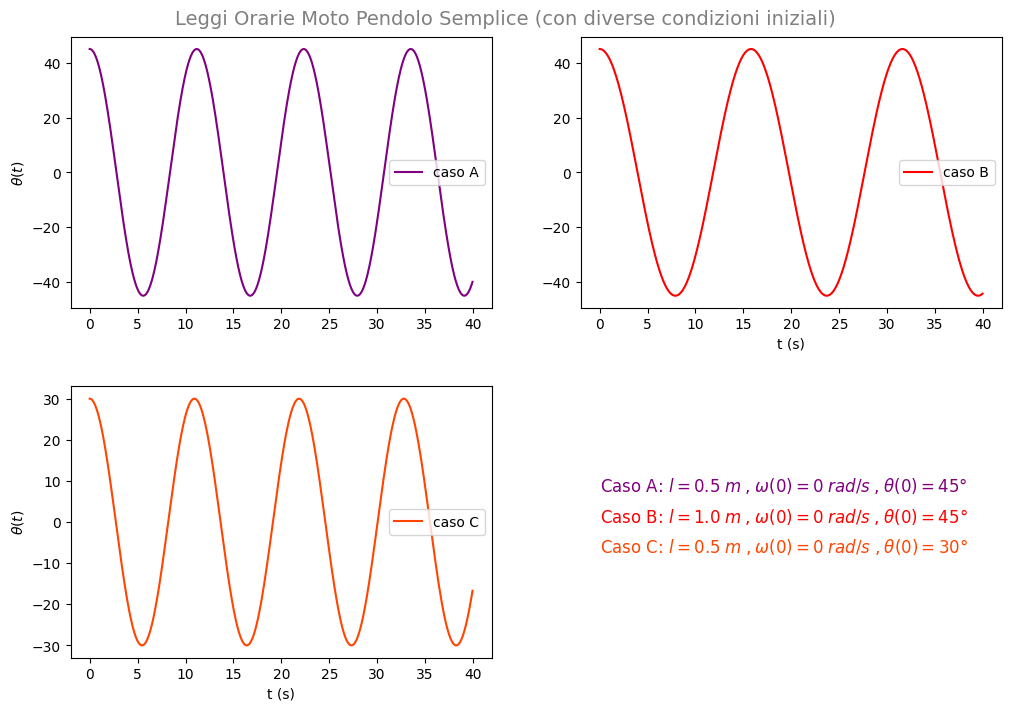

In [18]:
# Grafici soluzioni nei tre casi
fig = plt.figure(figsize=(10,7), layout='constrained')
gs = fig.add_gridspec(2,2, hspace=0.1, wspace=0.1)
(ax1, ax2), (ax3, ax4)= gs.subplots()
fig.suptitle('Leggi Orarie Moto Pendolo Semplice (con diverse condizioni iniziali)', fontsize=14, color='grey')

ax1.plot(time2, pa_solved[:,0], color='purple', label='caso A')
#ax1.set_xlabel('t (s)', fontsize=10)
ax1.set_ylabel(r'$\theta(t)$')
ax1.legend(fontsize=10)

ax2.plot(time2, pb_solved[:,0], color='red', label='caso B')
ax2.set_xlabel('t (s)', fontsize=10)
#ax2.set_ylabel(r'$\theta(t)$')
ax2.legend(fontsize=10)

ax3.plot(time2, pc_solved[:,0], color='orangered', label='caso C')
ax3.set_xlabel('t (s)', fontsize=10)
ax3.set_ylabel(r'$\theta(t)$')
ax3.legend(fontsize=10)

ax4.plot(time2,time2, alpha=0)
ax4.axis('off')
ax4.text(0,25, r'Caso A: $l=0.5 \; m\; \text{,} \; \omega(0)=0 \; rad/s \; \text{,} \; \theta(0) = 45°$', fontsize=12, color ='purple')
ax4.text(0,20, r'Caso B: $l=1.0  \;m \; \text{,} \; \omega(0)=0 \;rad/s  \; \text{,} \; \theta(0) = 45°$', fontsize=12, color ='red')
ax4.text(0,15, r'Caso C: $l=0.5    \;m \; \text{,} \; \omega(0)=0  \;rad/s \; \text{,} \; \theta(0) = 30°$', fontsize=12, color ='orangered')

plt.show()

#### Considerazioni Teoriche

Si nota che per i casi A e C, dove la lunghezza del filo è la stessa, le oscillazioni hanno la stessa pulsazione ma diversa ampiezza; mentre per i casi A e B, che partono dal medesimo angolo, ma la lunghezza del filo è diversa, le oscillazioni hanno stessa ampiezza ma diversa frequenza: la frequenza di A ($l=0.5$ m) è maggiore della frequenza di C ($l=1$ m).
Il fatto è ancora più chiaro se si considera che derivando l'equazione oraria:

$$ \theta (t) = \theta_0 \sin (\omega t + \phi) $$

e sostituendola nell'equazione differenziale, si ottiene: $ \omega (t) = \sqrt{ \frac{g}{l}} $

Dunque, la pulsazione non dipende dall'ampiezza iniziale ed è inversamente proporzionale alla radice quadrata della lunghezza della fune.

#### Grafico Animato

In [19]:
#Funzione per Animazione
def animate_pendulum(i, x, y, dt, line, mass, text):
    """
    Funzione pe animazione pendolo

    Assegna la posizione  istante per istante  agli ogetti da animare
    Il fulcro del pendolo è posizionato alle coordinate (0,0)

    Parametri:
    ----------

    i    : indice del frame 
    x    : array con coordinate x della massa del pendolo in funzione del tempo
    y    : array con coordinate y della massa del pendolo in funzione del tempo
    dt   : distanza temporale fra i punti dell'array dei tempi con cui si è risolta l'equazione del moto
    line : oggetto grafico  che rappresenta il filo di sospensione (plt.plot([0,x[i]],[0,yi[i]]))
    mass : oggetto grafico  che rappresenta la massa del pendolo   (plt.plot(   x[i],    yi[i] ))
    text : testo con tempo che scorre

    Restituisce:
    ------------
    return line, mass, text
    """
    
    line_x = [0, x[i]]
    line_y = [0, y[i]]
    line.set_data(line_x,line_y)

    mass_x = x[i]
    mass_y = y[i]
    mass.set_data(mass_x,mass_y)

    time_template = 'time = %.1fs'
    text.set_text(time_template % (i*dt))

    return line, mass, text

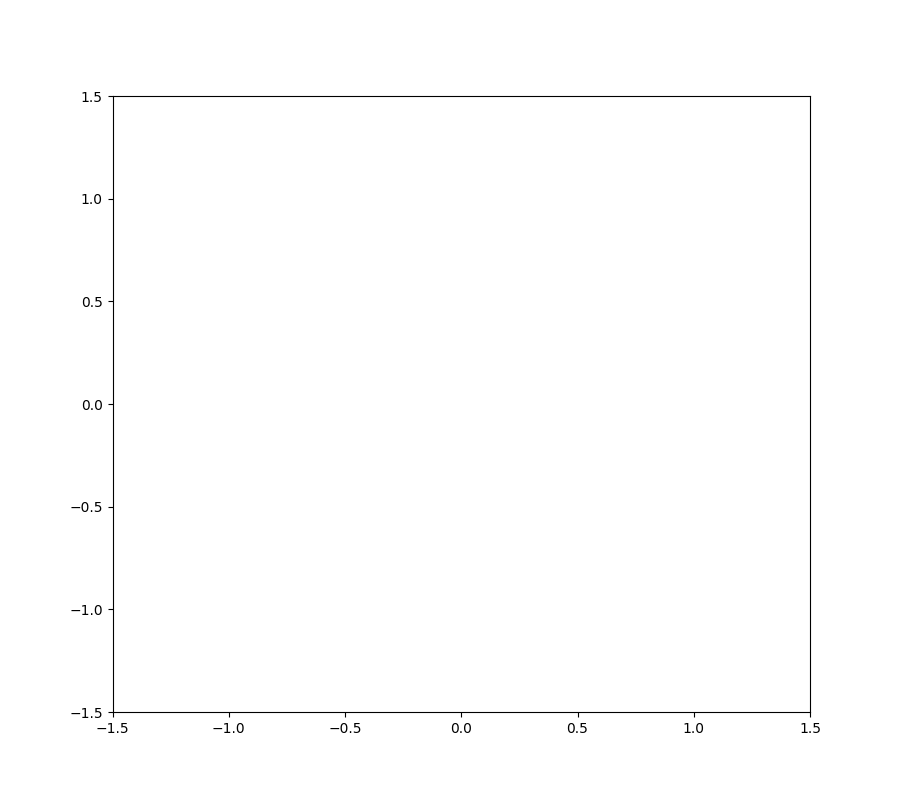

In [31]:
# Animazione caso A
# proiezione su asse x e y della soluzione. 
x1 =  1*np.sin(pa_solved[:, 0])
y1 = -1*np.cos(pa_solved[:, 0])


fig = plt.figure(figsize=(9,8))
ax  = fig.add_subplot(111, autoscale_on=False, xlim=(-1.5, 1.5), ylim=(-1.5, 1.5))
#ax.grid()

# Oggetti da animare (linea, massa, testo)
pendulum_line, = ax.plot([], [], 'o-', lw=2, markersize=5,  color='slategray')
pendulum_mass, = ax.plot([], [], 'o',        markersize=15, color='darkred'  )
time_text      = ax.text(0.05, 0.9, '', transform=ax.transAxes, fontsize=16)

# Animazione 
pendulum_ani = animation.FuncAnimation(
    fig,                                                        # Figura per animazione
    animate_pendulum,                                           # Funzione per animazione con calcolo oggetti ad ogni istante
    np.arange(1, len(y1)),                                      # valori su cui iterare (corripondente all'indice i in animate)
    fargs=( x1,y1,dt, pendulum_line, pendulum_mass, time_text), # argomenti aggiuntivi della funzione animate 
    interval=25,                                                # Intervallo fra due frame successivi (ms)
    blit=True)                                                  # Ottimizzazione grafica

## Esercizio 3

Data la seguente equazione del moto per un oscillatore armonico:
$$ \frac{d^2x}{dt^2} =  - \omega^2 x^3 $$

1. Risolvere l'equazione del moto per diverse condizioni iniziali;
2. Confrontare graficamente i risultati.

Si tratta di una equazione differenziale scalare al secondo ordine che può dunque essere risolta mediante un sistema di due equazioni al primo ordine definendo $ \frac{dx}{dt} \stackrel{.}{=} \mathbf{v}$: 
$$ \left( \frac{dx}{dt} = v \; \text{,} \; \frac{dv}{dt}= f(t,x)= - \omega^2 x^3 \right) $$

si risolve l'equazione per diverse condizioni iniziali.

In [45]:
#costanti del moto
pl=0.6 #rad/s

#condizioni iniziali
xx=np.arange(10, 50, 10) #m

vv1=np.zeros(4) #m/s
vv2=np.full(4,4.5) # 4.5m/s --> 16.2 km/h
pre1=np.empty(0)
pre2=np.empty(0)
for i,j,e in zip(xx, vv1, vv2):
    pre1=np.append(pre1, [i,j])
    pre2=np.append(pre2, [i,e])

#equazione diffrenziale del moto
def dxdt_osc(parx, tt, p):
    """
    dxdt_osc(par, tt, p, xx) equazione differenziale moto oscillatore armonico
    parx : posizione iniziale
    tt : variabile tempo
    p : pulsazione del moto 
    """
    dxdt=parx[1]
    dvdt= -p**2*parx[0]**3
    return (dxdt, dvdt)

dpre=2

In [ ]:
#Risoluzione eq.diff. per diverse condizioni iniziali

#velocità iniziale nulla
sol1_moto={'sol_moto1':0, 'sol_moto2':0, 'sol_moto3':0, 'sol_moto4':0}
for i,j in zip( np.arange(0, len(pre1), dpre), sol1_moto.keys()):
    sol=integrate.odeint(dxdt_osc, pre1[i:i+dpre], time1, args=(pl,))
    sol1_moto[j]=sol

#for k in sol1_moto:
    #print(k, sol1_moto[k],'\n')

#velocità iniziale non nulla
sol2_moto={'sol_moto1':0, 'sol_moto2':0, 'sol_moto3':0, 'sol_moto4':0}
for i,j in zip( np.arange(0, len(pre2), dpre), sol2_moto.keys()):
    sol=integrate.odeint(dxdt_osc, pre2[i:i+dpre], time1, args=(pl,))
    sol2_moto[j]=sol

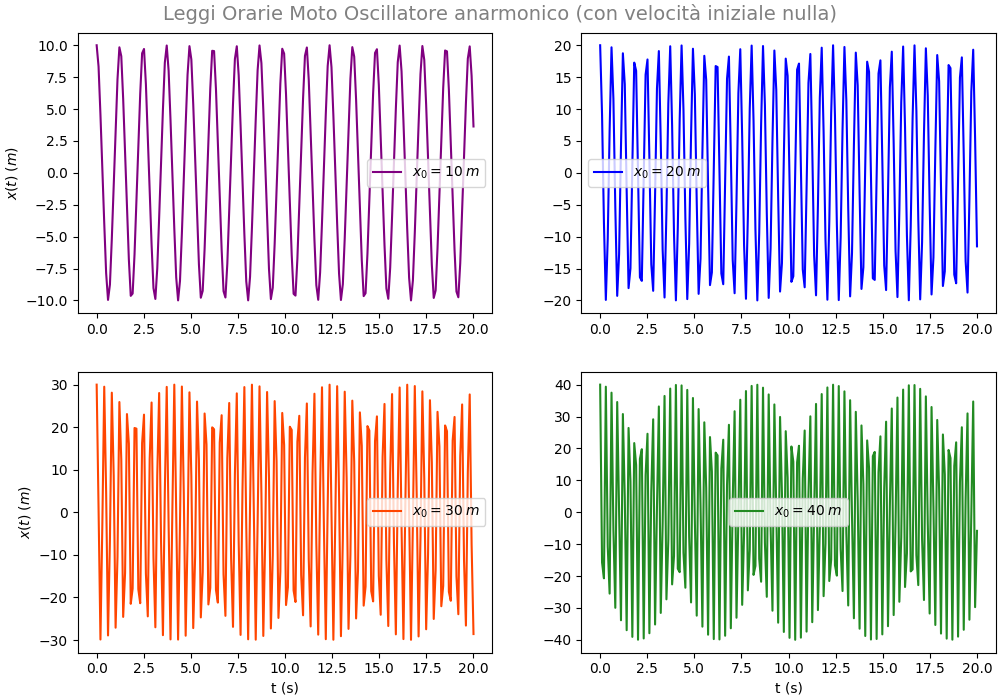

In [47]:
#grafici spazio-tempo, velocità iniziale nulla
fig = plt.figure(figsize=(10,7), layout='constrained')
gs = fig.add_gridspec(2,2, hspace=0.1, wspace=0.1)
(ax1, ax2), (ax3, ax4)= gs.subplots()
fig.suptitle('Leggi Orarie Moto Oscillatore anarmonico (con velocità iniziale nulla)', fontsize=14, color='grey')

ax1.plot(time1, sol1_moto['sol_moto1'][:,0], color='purple', label=r'$x_0= 10 \; m$')
#ax1.set_xlabel('t (s)', fontsize=10)
ax1.set_ylabel(r'$x(t) \; (m)$')
ax1.legend(fontsize=10)

ax2.plot(time1, sol1_moto['sol_moto2'][:,0], color='blue', label=r'$x_0= 20 \; m$')
#ax2.set_xlabel('t (s)', fontsize=10)
#ax2.set_ylabel(r'$\theta(t)$')
ax2.legend(fontsize=10)

ax3.plot(time1, sol1_moto['sol_moto3'][:,0], color='orangered', label=r'$x_0= 30 \; m$')
ax3.set_xlabel('t (s)', fontsize=10)
ax3.set_ylabel(r'$x(t) \; (m)$')
ax3.legend(fontsize=10)

ax4.plot(time1, sol1_moto['sol_moto4'][:,0], color='forestgreen', label=r'$x_0= 40 \; m$')
ax4.set_xlabel('t (s)', fontsize=10)
#ax4.set_ylabel(r'$x(t) (m)$')
ax4.legend(fontsize=10)


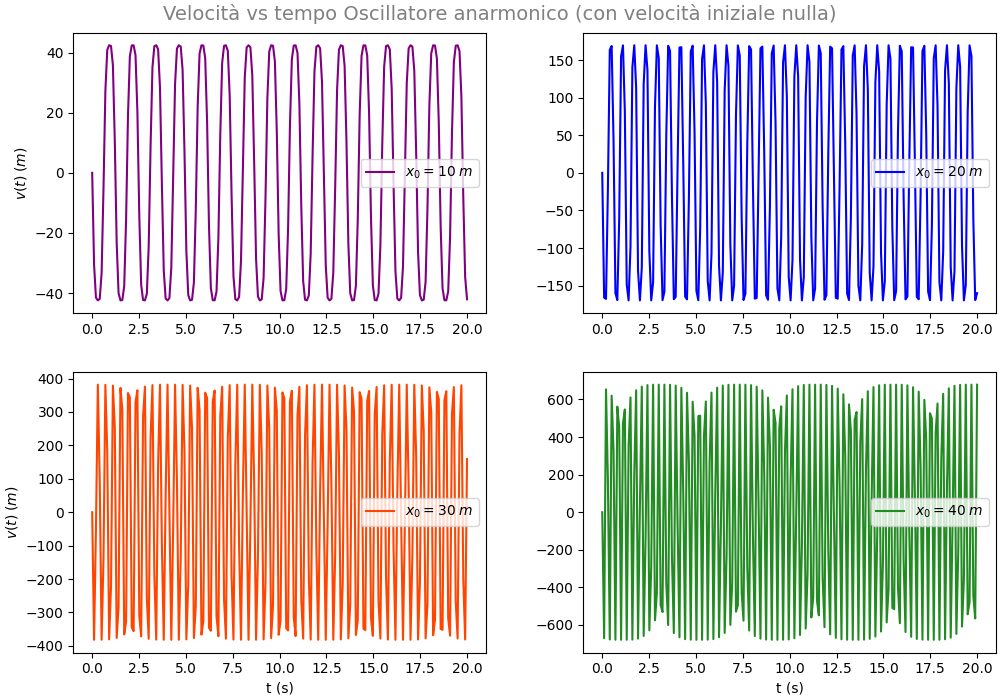

In [48]:
#grafici velocità-tempo, velocità iniziale nulla
fig = plt.figure(figsize=(10,7), layout='constrained')
gs = fig.add_gridspec(2,2, hspace=0.1, wspace=0.1)
(ax1, ax2), (ax3, ax4)= gs.subplots()
fig.suptitle('Velocità vs tempo Oscillatore anarmonico (con velocità iniziale nulla)', fontsize=14, color='grey')

ax1.plot(time1, sol1_moto['sol_moto1'][:,1], color='purple', label=r'$x_0= 10 \; m$')
#ax1.set_xlabel('t (s)', fontsize=10)
ax1.set_ylabel(r'$v(t) \; (m)$')
ax1.legend(fontsize=10)

ax2.plot(time1, sol1_moto['sol_moto2'][:,1], color='blue', label=r'$x_0= 20 \; m$')
#ax2.set_xlabel('t (s)', fontsize=10)
#ax2.set_ylabel(r'$\theta(t)$')
ax2.legend(fontsize=10)

ax3.plot(time1, sol1_moto['sol_moto3'][:,1], color='orangered', label=r'$x_0= 30 \; m$')
ax3.set_xlabel('t (s)', fontsize=10)
ax3.set_ylabel(r'$v(t) \; (m)$')
ax3.legend(fontsize=10)

ax4.plot(time1, sol1_moto['sol_moto4'][:,1], color='forestgreen', label=r'$x_0= 40 \; m$')
ax4.set_xlabel('t (s)', fontsize=10)
#ax4.set_ylabel(r'$x(t) (m)$')
ax4.legend(fontsize=10)

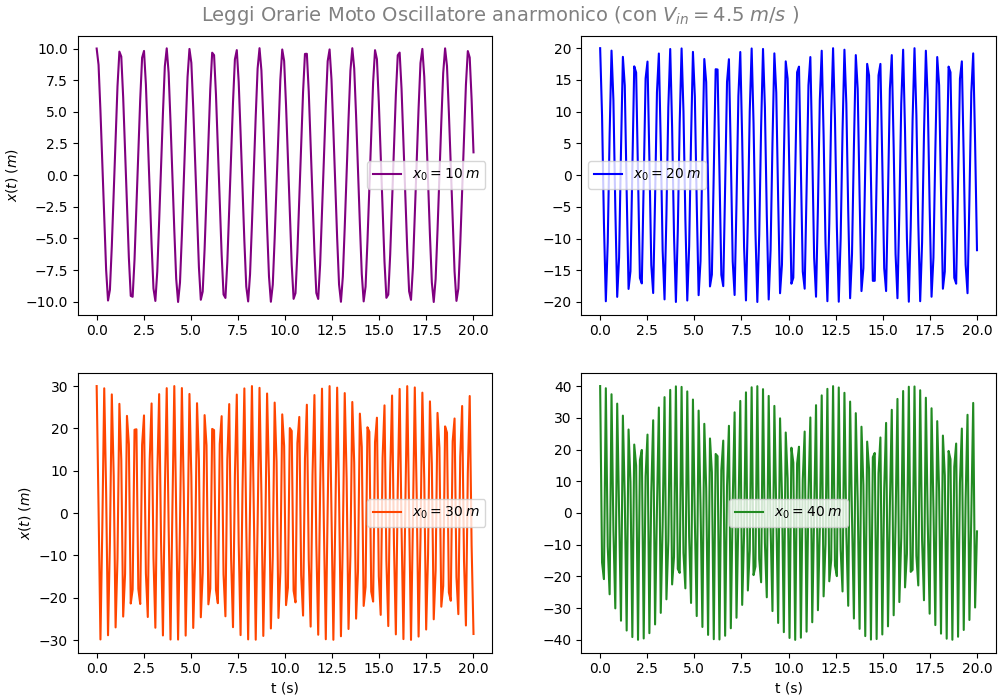

In [49]:
#grafici spazio-tempo, velocità iniziale 16.2 km/h
fig = plt.figure(figsize=(10,7), layout='constrained')
gs = fig.add_gridspec(2,2, hspace=0.1, wspace=0.1)
(ax1, ax2), (ax3, ax4)= gs.subplots()
fig.suptitle('Leggi Orarie Moto Oscillatore anarmonico (con $V_{in} = 4.5 \; m/s$ )', fontsize=14, color='grey')

ax1.plot(time1, sol2_moto['sol_moto1'][:,0], color='purple', label=r'$x_0= 10 \; m$')
#ax1.plot(time1, sol1_moto['sol_moto1'][:,0], color='green', label=r'$x_0= 10 \; m$', linestyle='--')
#ax1.set_xlabel('t (s)', fontsize=10)
ax1.set_ylabel(r'$x(t) \; (m)$')
ax1.legend(fontsize=10)

ax2.plot(time1, sol2_moto['sol_moto2'][:,0], color='blue', label=r'$x_0= 20 \; m$')
#ax2.set_xlabel('t (s)', fontsize=10)
#ax2.set_ylabel(r'$\theta(t)$')
ax2.legend(fontsize=10)

ax3.plot(time1, sol2_moto['sol_moto3'][:,0], color='orangered', label=r'$x_0= 30 \; m$')
#ax3.plot(time1, sol1_moto['sol_moto3'][:,0], color='green', label=r'$x_0= 30 \; m$', linestyle='--')
ax3.set_xlabel('t (s)', fontsize=10)
ax3.set_ylabel(r'$x(t) \; (m)$')
ax3.legend(fontsize=10)

ax4.plot(time1, sol2_moto['sol_moto4'][:,0], color='forestgreen', label=r'$x_0= 40 \; m$')
ax4.set_xlabel('t (s)', fontsize=10)
#ax4.set_ylabel(r'$x(t) (m)$')
ax4.legend(fontsize=10)

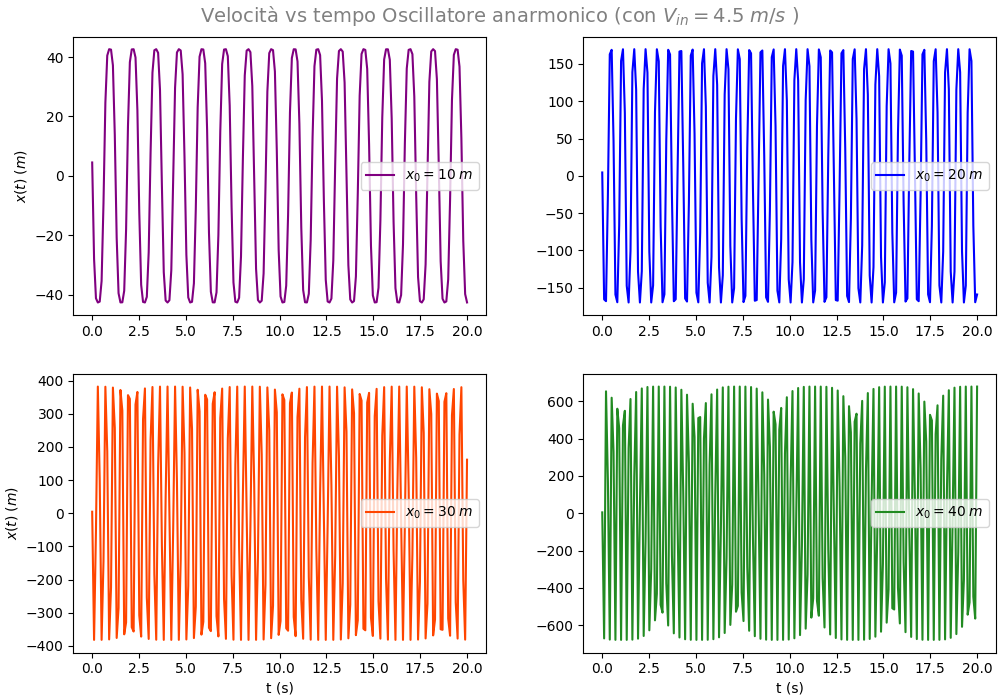

In [50]:
#grafici velocità-tempo, velocità iniziale 16.2 Km/h
fig = plt.figure(figsize=(10,7), layout='constrained')
gs = fig.add_gridspec(2,2, hspace=0.1, wspace=0.1)
(ax1, ax2), (ax3, ax4)= gs.subplots()
fig.suptitle('Velocità vs tempo Oscillatore anarmonico (con $V_{in} = 4.5 \; m/s$ ) ', fontsize=14, color='grey')

ax1.plot(time1, sol2_moto['sol_moto1'][:,1], color='purple', label=r'$x_0= 10 \; m$')
#ax1.plot(time1, sol1_moto['sol_moto1'][:,1], color='green', label=r'$x_0= 10 \; m$', linestyle='--')
#ax1.set_xlabel('t (s)', fontsize=10)
ax1.set_ylabel(r'$x(t) \; (m)$')
ax1.legend(fontsize=10)

ax2.plot(time1, sol2_moto['sol_moto2'][:,1], color='blue', label=r'$x_0= 20 \; m$')
#ax2.set_xlabel('t (s)', fontsize=10)
#ax2.set_ylabel(r'$\theta(t)$')
ax2.legend(fontsize=10)

ax3.plot(time1, sol2_moto['sol_moto3'][:,1], color='orangered', label=r'$x_0= 30 \; m$')
#ax3.plot(time1, sol1_moto['sol_moto3'][:,1], color='green', label=r'$x_0= 30 \; m$', linestyle='--')
ax3.set_xlabel('t (s)', fontsize=10)
ax3.set_ylabel(r'$x(t) \; (m)$')
ax3.legend(fontsize=10)

ax4.plot(time1, sol2_moto['sol_moto4'][:,1], color='forestgreen', label=r'$x_0= 40 \; m$')
ax4.set_xlabel('t (s)', fontsize=10)
#ax4.set_ylabel(r'$x(t) (m)$')
ax4.legend(fontsize=10)